##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

 Image File            Predicted (>=0.5) True Label Correct? (Yes/No) Missed? Wrong/Other labels
bicycle.jpg               bicycle (0.98)    bicycle               Yes                          -
    bus.jpg                   bus (0.99)        bus               Yes                          -
    cat.jpg                   cat (0.89)        cat               Yes                          -
 person.jpg person (0.97), person (0.96)     person               Yes                          -
  puppy.jpg                   dog (0.95)        dog               Yes                          -


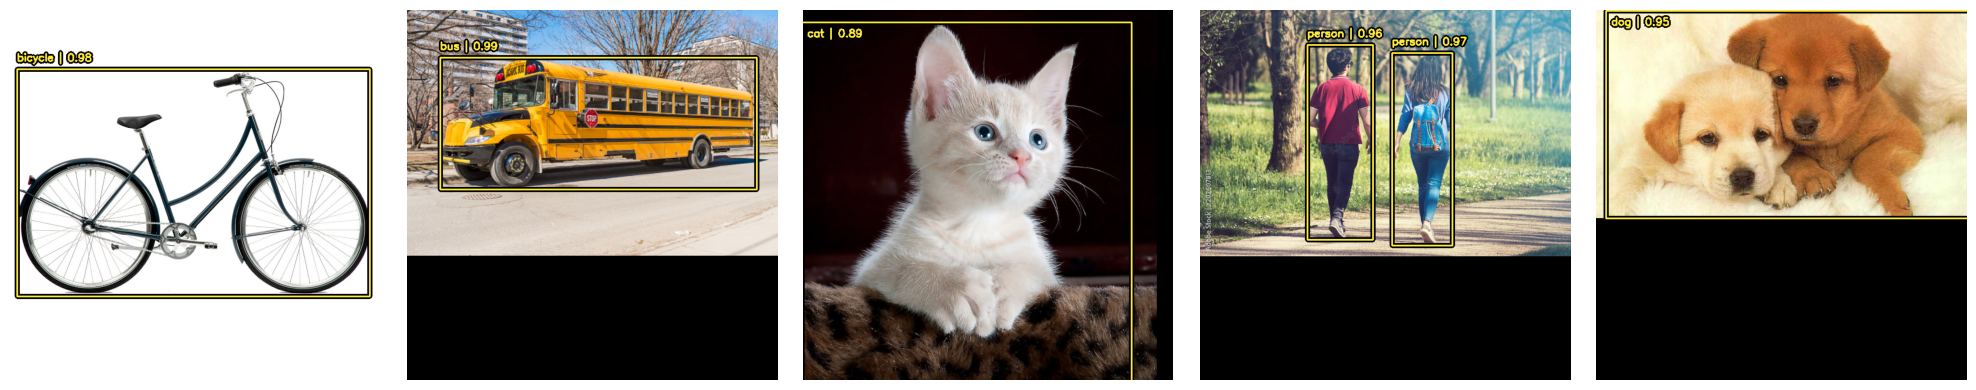

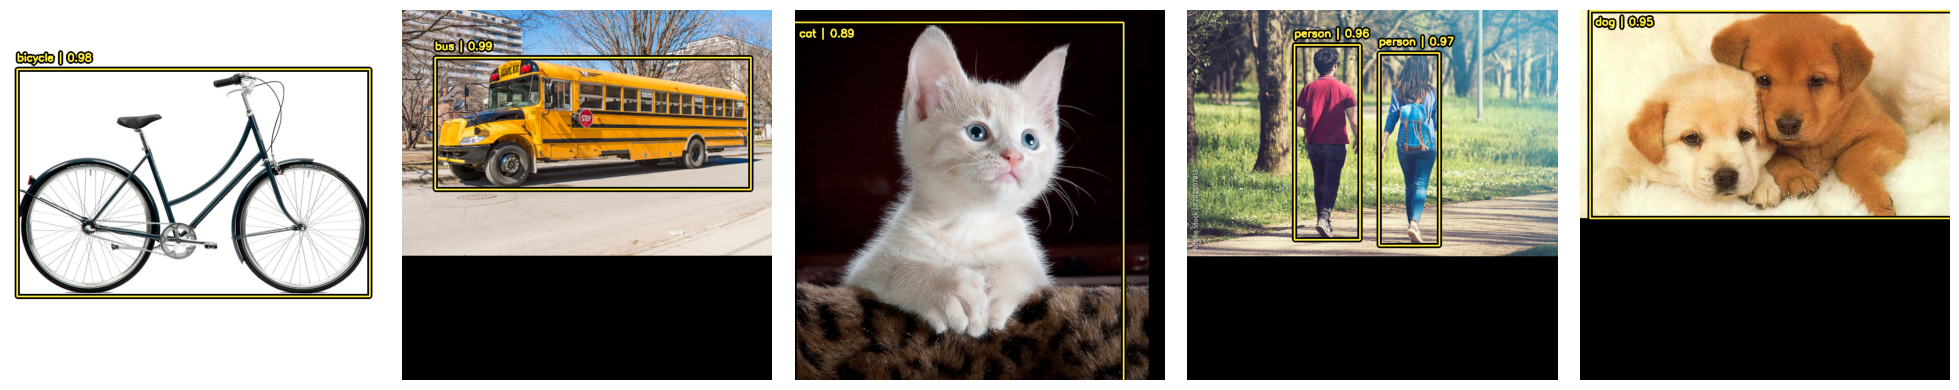

In [4]:
# Install compatible packages for Colab
!pip -q install -U "keras-cv" "keras>=3.0.0" "pandas==2.2.2" "pillow==11.3.0" matplotlib

# Imports
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import keras_cv
from keras_cv import visualization

# Load pretrained YOLOv8 model (Pascal VOC preset)
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

# Instructor-required resizing layer for inference
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# Pascal VOC class mapping (20 classes)
voc_classes = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor",
]
class_mapping = {i: n for i, n in enumerate(voc_classes)}

# Your uploaded images in /content
images_info = [
    {"file": "bicycle.jpg", "path": "/content/bicycle.jpg", "true": "bicycle"},
    {"file": "bus.jpg", "path": "/content/bus.jpg", "true": "bus"},
    {"file": "cat.jpg", "path": "/content/cat.jpg", "true": "cat"},
    {"file": "person.jpg", "path": "/content/person.jpg", "true": "person"},
    {"file": "puppy.jpg", "path": "/content/puppy.jpg", "true": "dog"},  # VOC label is "dog"
]

# Load + resize each image individually (fix for non-rectangular tensor error)
resized_images = []
for x in images_info:
    img = keras.utils.load_img(x["path"])
    img = np.array(img)  # uint8 HxWx3
    img = tf.convert_to_tensor(img)
    img = tf.expand_dims(img, axis=0)            # (1, H, W, 3)
    img = inference_resizing(img)                # (1, 640, 640, 3)
    resized_images.append(img[0])                # (640, 640, 3)

image_batch = tf.stack(resized_images, axis=0)   # (5, 640, 640, 3)

# Run YOLOv8 inference
y_pred = model.predict(image_batch, verbose=0)

# Record results
conf_threshold = 0.5
rows = []

for i, info in enumerate(images_info):
    true_label = info["true"]
    img_file = info["file"]

    boxes = y_pred["boxes"][i]
    classes = y_pred["classes"][i].astype("int32")
    confs = y_pred["confidence"][i]

    keep = confs >= conf_threshold
    classes_k = classes[keep]
    confs_k = confs[keep]

    detected_names = [class_mapping.get(int(c), f"class_{int(c)}") for c in classes_k]
    detected_pairs = [f"{n} ({float(s):.2f})" for n, s in zip(detected_names, confs_k)]

    correct = "Yes" if true_label in detected_names else "No"
    missed = "" if correct == "Yes" else true_label
    wrong = ", ".join(sorted(set([n for n in detected_names if n != true_label])))

    rows.append({
        "Image File": img_file,
        "Predicted (>=0.5)": ", ".join(detected_pairs) if detected_pairs else "No detections >= 0.5",
        "True Label": true_label,
        "Correct? (Yes/No)": correct,
        "Missed?": missed,
        "Wrong/Other labels": wrong if wrong else "-"
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Visualize detections (boxes + labels + confidence)
visualization.plot_bounding_box_gallery(
    image_batch,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=y_pred,
    scale=4,
    font_scale=0.6,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)

RESULTS:
| Image File  | Detected correctly?        | Confidence score(s) | Missed objects | Incorrectly labeled objects |
| ----------- | -------------------------- | ------------------- | -------------- | --------------------------- |
| bicycle.jpg | bicycle                    | 0.98                | None           | None                        |
| bus.jpg     | bus                        | 0.99                | None           | None                        |
| cat.jpg     | cat                        | 0.89                | None           | None                        |
| person.jpg  | person (2 people detected) | 0.97, 0.96          | None           | None                        |
| puppy.jpg   | dog                        | 0.95                | None           | None                        |
